# Synthetic MFA K/q Sweep Results

Use this notebook after the per-setting sweep jobs have written `metrics.pt` files. The collection cell rebuilds `results.csv`, `results.pt`, and `config.json`; each later cell displays and saves exactly one plot.

In [1]:
from __future__ import annotations

import csv
import json
import os
import sys
from pathlib import Path

import pandas as pd
import torch
from IPython.display import display

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from dalg.models.mfa import MFA

MODEL_ROOT = REPO_ROOT / "dalg-cache/qk_sweep_exploration"
RUN_NAME = "Ktrue1000_qtrue20"
RUN_DIR = MODEL_ROOT / RUN_NAME
PLOT_DIR = RUN_DIR / "notebook_plots"

(PLOT_DIR / ".matplotlib").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(PLOT_DIR / ".matplotlib"))
import matplotlib.pyplot as plt

RUN_DIR

PosixPath('/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20')

In [2]:
def _json_safe(obj):
    if isinstance(obj, dict):
        return {key: _json_safe(value) for key, value in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_safe(value) for value in obj]
    if isinstance(obj, Path):
        return str(obj)
    return obj


def _scalar_row(row: dict) -> dict:
    return {
        key: value
        for key, value in row.items()
        if isinstance(value, (str, int, float, bool)) or value is None
    }


def write_csv(rows: list[dict], path: Path) -> None:
    scalar_rows = [_scalar_row(row) for row in rows]
    fieldnames = sorted({key for row in scalar_rows for key in row})
    with path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(scalar_rows)


def _load_existing_config(run_dir: Path) -> dict:
    candidates = [run_dir / "config.json", *sorted(run_dir.glob("K*_q*_seed*/config.json"))]
    for path in candidates:
        if path.exists():
            return json.loads(path.read_text())
    return {}


def collect_results(run_dir: Path) -> tuple[list[dict], dict]:
    rows = [
        torch.load(path, map_location="cpu", weights_only=False)
        for path in sorted(run_dir.glob("K*_q*_seed*/metrics.pt"))
    ]
    if not rows:
        raise FileNotFoundError(f"No metrics.pt files found under {run_dir}")

    cfg = _load_existing_config(run_dir)
    cfg["model_root"] = str(run_dir.parent)
    cfg["run_name"] = run_dir.name
    cfg["K_fit"] = sorted({int(row["K_fit"]) for row in rows})
    cfg["q_fit"] = sorted({int(row["q_fit"]) for row in rows})
    cfg["K_true"] = int(cfg.get("K_true", rows[0]["K_true"]))
    cfg["q_true"] = int(cfg.get("q_true", rows[0]["q_true"]))
    cfg["D"] = int(cfg.get("D", rows[0]["D"]))

    run_dir.mkdir(parents=True, exist_ok=True)
    write_csv(rows, run_dir / "results.csv")
    torch.save(rows, run_dir / "results.pt")
    (run_dir / "config.json").write_text(json.dumps(_json_safe(cfg), indent=2))
    return rows, cfg

In [3]:
rows, cfg = collect_results(RUN_DIR)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

results = pd.DataFrame([_scalar_row(row) for row in rows])
display(results.sort_values(["K_fit", "q_fit", "seed"]).head())
print(f"Collected {len(rows)} fits from {RUN_DIR}")
print(f"Plots will be saved to {PLOT_DIR}")

,seed,K_true,q_true,D,K_fit,q_fit,train_nll,test_nll,best_epoch,best_val_metric,train_hungarian_accuracy,mean_entropy,norm_mean_entropy,mean_max_resp,mean_top1_minus_top2,hungarian_accuracy,adjusted_rand,normalized_mutual_info,empty_clusters
0,0,1000,20,500,10,5,453.287975,453.544701,27,453.544688,0.010926,0.073309,0.031838,0.978755,0.959649,0.0169,0.000751,0.195664,0
1,0,1000,20,500,10,10,451.843591,452.343264,38,452.343267,0.011004,0.074129,0.032194,0.977122,0.956493,0.0168,0.001409,0.267168,0
2,0,1000,20,500,10,15,450.641501,451.158477,73,451.158451,0.011022,0.081917,0.035576,0.973712,0.950612,0.0170,0.002572,0.335311,0
3,0,1000,20,500,10,20,449.554531,450.045039,87,450.045048,0.011012,0.080580,0.034995,0.974082,0.952056,0.0173,0.004294,0.386172,0
4,0,1000,20,500,10,25,448.516456,449.114938,37,449.114944,0.011062,0.078632,0.034149,0.973700,0.952057,0.0180,0.006570,0.422796,0


Collected 228 fits from /orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20
Plots will be saved to /orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots


## Evaluate overlap g.t gaussians

In [4]:
def ground_truth_responsibility_peakness(dataset_path: Path, *, batch_size: int = 4096) -> float:
    dataset = torch.load(dataset_path, map_location="cpu", weights_only=False)
    state = dataset["truth"]
    mu = state["mu"].detach().cpu()
    truth = MFA(
        mu,
        rank=int(state["dir_raw"].shape[-1]),
        psi_per_component=state["psi_rho"].ndim == 2,
    )
    truth.load_state_dict(state)
    truth.eval()

    x = dataset["x_test"]
    total_peakness = 0.0
    total_n = 0
    with torch.no_grad(), truth.inference_cache():
        for start in range(0, x.shape[0], batch_size):
            xb = x[start : start + batch_size]
            peak = truth.responsibilities(xb).max(dim=1).values
            total_peakness += float(peak.sum().item())
            total_n += int(peak.numel())
    return total_peakness / max(total_n, 1)


dataset_path = Path(cfg["dataset_path"])
ground_truth_peakness = ground_truth_responsibility_peakness(dataset_path)
ground_truth_overlap = {
    "dataset_path": str(dataset_path),
    "split": "x_test",
    "mean_max_responsibility": ground_truth_peakness,
}
(RUN_DIR / "ground_truth_overlap.json").write_text(json.dumps(ground_truth_overlap, indent=2))
display(pd.DataFrame([ground_truth_overlap]))

,dataset_path,split,mean_max_responsibility
0,/orfeo/scratch/dssc/zenocosini/dalg-cache/asse...,x_test,1.0


## Bhattacharyya distance matrices by q

The heavy overlap computation lives in `scripts/synthetic_mfa_bhattacharyya_by_q.py`; it writes `overlap.pt` next to each fitted model and a small summary file in the run directory. The cells below only load those artifacts and plot them.


In [4]:
BHATTACHARYYA_K = 2000#cfg["K_fit"][0]
available_seeds_for_K = sorted(
    {int(row["seed"]) for row in rows if int(row["K_fit"]) == int(BHATTACHARYYA_K)}
)
BHATTACHARYYA_SEED = available_seeds_for_K[0]
BHATTACHARYYA_METRIC = "db"
BHATTACHARYYA_PARALLEL = 0
BHATTACHARYYA_WORKERS = 2
BHATTACHARYYA_SUMMARY_PT = (
    RUN_DIR / f"bhattacharyya_by_q_K{BHATTACHARYYA_K:04d}_seed{BHATTACHARYYA_SEED:04d}.pt"
)

print(f"K={BHATTACHARYYA_K}")
print(f"seed={BHATTACHARYYA_SEED}")
print(f"available seeds for K: {available_seeds_for_K}")
print(f"summary: {BHATTACHARYYA_SUMMARY_PT}")


K=2000
seed=0
available seeds for K: [0]
summary: /orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/bhattacharyya_by_q_K2000_seed0000.pt


In [5]:
def fit_dir_for(K_fit: int, q_fit: int, seed: int) -> Path:
    return RUN_DIR / f"K{K_fit:04d}_q{q_fit:04d}_seed{seed:04d}"


def bhattacharyya_script_command() -> str:
    parallel_args = (
        f" --parallel --workers {BHATTACHARYYA_WORKERS}"
        if BHATTACHARYYA_PARALLEL
        else ""
    )
    return (
        f"PYTHONPATH=src python scripts/synthetic_mfa_bhattacharyya_by_q.py "
        f"--run-dir {RUN_DIR} --k-fit {BHATTACHARYYA_K} "
        f"--seed {BHATTACHARYYA_SEED} --metric {BHATTACHARYYA_METRIC}"
        f"{parallel_args}"
    )


if not BHATTACHARYYA_SUMMARY_PT.exists():
    raise FileNotFoundError(
        f"{BHATTACHARYYA_SUMMARY_PT} not found. Run the analysis script first:\n"
        f"  {bhattacharyya_script_command()}"
    )

_bhatt = torch.load(BHATTACHARYYA_SUMMARY_PT, map_location="cpu", weights_only=False)
bhattacharyya_summary = (
    pd.DataFrame(_bhatt["rows"])
    .sort_values(["K_fit", "q_fit", "seed"])
    .reset_index(drop=True)
)
bhattacharyya_summary = bhattacharyya_summary[
    (bhattacharyya_summary["K_fit"] == BHATTACHARYYA_K)
    & (bhattacharyya_summary["seed"] == BHATTACHARYYA_SEED)
]
if "metric" in bhattacharyya_summary:
    bhattacharyya_summary = bhattacharyya_summary[
        bhattacharyya_summary["metric"] == BHATTACHARYYA_METRIC
    ]

q_values_for_K_seed = sorted(int(q) for q in bhattacharyya_summary["q_fit"].unique())
missing_overlap_paths = []
bhattacharyya_mats = {}
for q_fit in q_values_for_K_seed:
    overlap_path = fit_dir_for(BHATTACHARYYA_K, q_fit, BHATTACHARYYA_SEED) / "overlap.pt"
    if not overlap_path.exists():
        missing_overlap_paths.append(overlap_path)
        continue
    overlap = torch.load(overlap_path, map_location="cpu", weights_only=False)
    if BHATTACHARYYA_METRIC not in overlap:
        raise KeyError(f"{BHATTACHARYYA_METRIC!r} not found in {overlap_path}")
    bhattacharyya_mats[q_fit] = overlap[BHATTACHARYYA_METRIC].detach().cpu()

if missing_overlap_paths:
    missing = "\n".join(f"  {path}" for path in missing_overlap_paths)
    raise FileNotFoundError(
        f"Missing overlap files:\n{missing}\n"
        f"Run the analysis script first:\n  {bhattacharyya_script_command()}"
    )

if not bhattacharyya_mats:
    raise FileNotFoundError(
        f"No precomputed Bhattacharyya matrices found for "
        f"K={BHATTACHARYYA_K}, seed={BHATTACHARYYA_SEED}.\n"
        f"Run: {bhattacharyya_script_command()}"
    )

display(bhattacharyya_summary)
print(f"Loaded {len(bhattacharyya_mats)} Bhattacharyya matrices")


,K_fit,q_fit,seed,metric,matrix_shape,mean_offdiag,min_offdiag,max_offdiag,overlap_path,status,seconds
0,2000,5,0,db,"(2000, 2000)",35.410717,2.956078,55.545223,dalg-cache/qk_sweep_exploration/Ktrue1000_qtru...,computed,12.671563
1,2000,10,0,db,"(2000, 2000)",37.274845,3.638725,58.116749,dalg-cache/qk_sweep_exploration/Ktrue1000_qtru...,computed,24.592958
2,2000,15,0,db,"(2000, 2000)",38.533936,3.720271,60.179573,dalg-cache/qk_sweep_exploration/Ktrue1000_qtru...,computed,37.686234
3,2000,20,0,db,"(2000, 2000)",39.973396,4.288458,61.887283,dalg-cache/qk_sweep_exploration/Ktrue1000_qtru...,computed,49.318034
4,2000,25,0,db,"(2000, 2000)",39.878403,3.912664,62.240936,dalg-cache/qk_sweep_exploration/Ktrue1000_qtru...,computed,63.158808
5,2000,30,0,db,"(2000, 2000)",39.263573,3.565202,61.763691,dalg-cache/qk_sweep_exploration/Ktrue1000_qtru...,computed,75.052718
6,2000,35,0,db,"(2000, 2000)",39.860382,3.813344,62.620178,dalg-cache/qk_sweep_exploration/Ktrue1000_qtru...,computed,87.294062
7,2000,40,0,db,"(2000, 2000)",38.757172,3.262754,61.389633,dalg-cache/qk_sweep_exploration/Ktrue1000_qtru...,computed,95.508590
8,2000,60,0,db,"(2000, 2000)",38.358334,3.087092,61.079967,dalg-cache/qk_sweep_exploration/Ktrue1000_qtru...,computed,141.783434
9,2000,80,0,db,"(2000, 2000)",39.326511,3.392964,62.595993,dalg-cache/qk_sweep_exploration/Ktrue1000_qtru...,computed,197.959243


Loaded 17 Bhattacharyya matrices


In [ ]:
try:
    import plotly.graph_objects as go
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install plotly to run this cell, for example with `uv pip install plotly`.") from exc

BHATTACHARYYA_COLOR_QUANTILE = 0.98

if "bhattacharyya_mats" not in globals() or not bhattacharyya_mats:
    command = (
        bhattacharyya_script_command()
        if "bhattacharyya_script_command" in globals()
        else "PYTHONPATH=src python scripts/synthetic_mfa_bhattacharyya_by_q.py --run-dir <RUN_DIR> --k-fit <K> --seed <SEED>"
    )
    raise FileNotFoundError(
        "Heatmap data is not loaded. Run the loader cell above after launching:\n"
        f"  {command}"
    )

q_values = sorted(bhattacharyya_mats)
z_values = [bhattacharyya_mats[q].float().numpy() for q in q_values]
# Use a deterministic subsample for the color-scale quantile. For large K,
# concatenating every matrix entry can exceed torch.quantile's input limit,
# while the heatmap frames below still use the full matrices.
_quantile_chunks = []
for _mat in bhattacharyya_mats.values():
    _vals = _mat.flatten()
    _vals = _vals[_vals > 0]
    if _vals.numel() > 200_000:
        _step = max(1, _vals.numel() // 200_000)
        _vals = _vals[::_step]
    _quantile_chunks.append(_vals.float())
positive_values = torch.cat(_quantile_chunks) if _quantile_chunks else torch.empty(0)
zmax = float(torch.quantile(positive_values, BHATTACHARYYA_COLOR_QUANTILE).item()) if positive_values.numel() else 1.0

fig = go.Figure(
    data=[
        go.Heatmap(
            z=z_values[0],
            zmin=0.0,
            zmax=zmax,
            colorscale="Viridis",
            colorbar={"title": "D_B"},
        )
    ],
    frames=[
        go.Frame(
            name=str(q),
            data=[go.Heatmap(z=z, zmin=0.0, zmax=zmax, colorscale="Viridis")],
            layout=go.Layout(title_text=f"Bhattacharyya distance, K={BHATTACHARYYA_K}, q={q}, seed={BHATTACHARYYA_SEED}"),
        )
        for q, z in zip(q_values, z_values)
    ],
)
fig.update_layout(
    title=f"Bhattacharyya distance, K={BHATTACHARYYA_K}, q={q_values[0]}, seed={BHATTACHARYYA_SEED}",
    xaxis_title="component j",
    yaxis_title="component i",
    width=760,
    height=720,
    updatemenus=[
        {
            "type": "buttons",
            "showactive": False,
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [None, {"frame": {"duration": 650, "redraw": True}, "fromcurrent": True}],
                },
                {
                    "label": "Pause",
                    "method": "animate",
                    "args": [[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}],
                },
            ],
        }
    ],
    sliders=[
        {
            "active": 0,
            "currentvalue": {"prefix": "q = "},
            "steps": [
                {
                    "label": str(q),
                    "method": "animate",
                    "args": [[str(q)], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
                }
                for q in q_values
            ],
        }
    ],
)
html_path = PLOT_DIR / f"bhattacharyya_distance_K{BHATTACHARYYA_K:04d}_seed{BHATTACHARYYA_SEED:04d}.html"
fig.write_html(html_path, include_plotlyjs="cdn")
fig.show()
print(html_path)

## Plot

In [8]:
PLOT_SPECS = {
    "mean_entropy": "Mean responsibility entropy",
    "norm_mean_entropy": "Mean entropy / log(K_fit)",
    "mean_max_resp": "Mean max responsibility",
    "mean_top1_minus_top2": "Mean top1 - top2 responsibility",
    "hungarian_accuracy": "Hungarian-matched accuracy",
    "adjusted_rand": "Adjusted Rand index",
    "normalized_mutual_info": "Normalized mutual information",
    "test_nll": "Test NLL",
}

BOUNDED_METRICS = {
    "hungarian_accuracy",
    "adjusted_rand",
    "normalized_mutual_info",
    "mean_max_resp",
    "mean_top1_minus_top2",
}


def mean_metric(metric: str, *, K_fit: int, q_fit: int) -> float:
    values = [
        float(row[metric])
        for row in rows
        if int(row["K_fit"]) == int(K_fit) and int(row["q_fit"]) == int(q_fit)
    ]
    if not values:
        return float("nan")
    return float(sum(values) / len(values))


def save_and_show(fig, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    display(fig)
    plt.close(fig)
    print(path)


def plot_metric_vs_q(metric: str) -> None:
    title = PLOT_SPECS[metric]
    q_values = list(cfg["q_fit"])
    q_positions = list(range(len(q_values)))
    fig_width = max(9.0, 0.38 * len(q_values) + 3.0)
    fig, ax = plt.subplots(figsize=(fig_width, 5))
    for K in cfg["K_fit"]:
        values = [mean_metric(metric, K_fit=K, q_fit=q) for q in q_values]
        ax.plot(q_positions, values, marker="o", linewidth=1.5, markersize=5, label=f"K={K}")
    if cfg.get("q_true") in q_values:
        ax.axvline(q_values.index(cfg["q_true"]), color="black", linestyle="--", linewidth=1, label="q true")
    ax.set_title(title)
    ax.set_xlabel("q_fit")
    ax.set_ylabel(metric)
    ax.set_xticks(q_positions)
    ax.set_xticklabels([str(q) for q in q_values], rotation=45, ha="right")
    ax.grid(True, axis="both", alpha=0.25)
    if metric in BOUNDED_METRICS:
        ax.set_ylim(-0.03, 1.03)
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True)
    save_and_show(fig, PLOT_DIR / f"{metric}_vs_q.png")


def plot_metric_heatmap(metric: str) -> None:
    title = PLOT_SPECS[metric]
    grid = [
        [mean_metric(metric, K_fit=K, q_fit=q) for q in cfg["q_fit"]]
        for K in cfg["K_fit"]
    ]
    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(grid, aspect="auto", origin="lower")
    ax.set_title(title)
    ax.set_xlabel("q_fit")
    ax.set_ylabel("K_fit")
    ax.set_xticks(range(len(cfg["q_fit"])))
    ax.set_xticklabels([str(q) for q in cfg["q_fit"]])
    ax.set_yticks(range(len(cfg["K_fit"])))
    ax.set_yticklabels([str(K) for K in cfg["K_fit"]])
    fig.colorbar(im, ax=ax, label=metric)
    save_and_show(fig, PLOT_DIR / f"{metric}_heatmap.png")

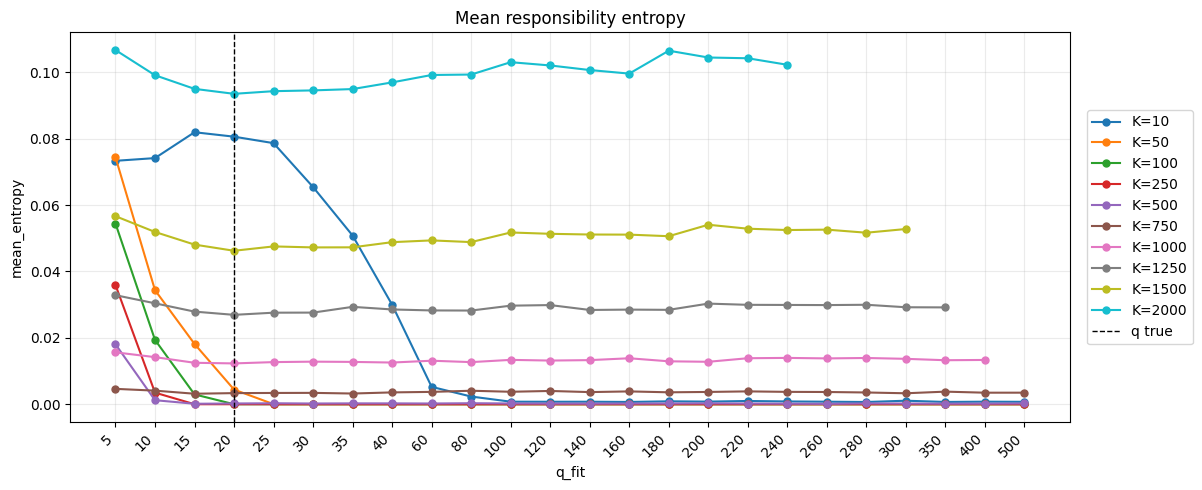

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/mean_entropy_vs_q.png


In [9]:
plot_metric_vs_q("mean_entropy")

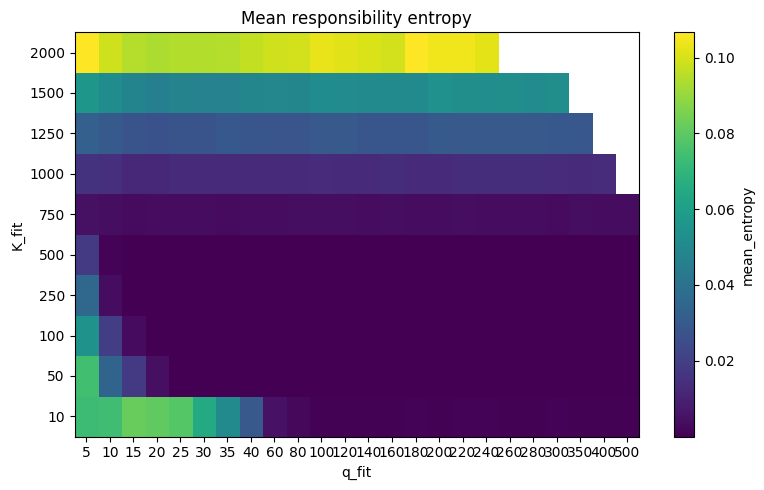

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/mean_entropy_heatmap.png


In [10]:
plot_metric_heatmap("mean_entropy")

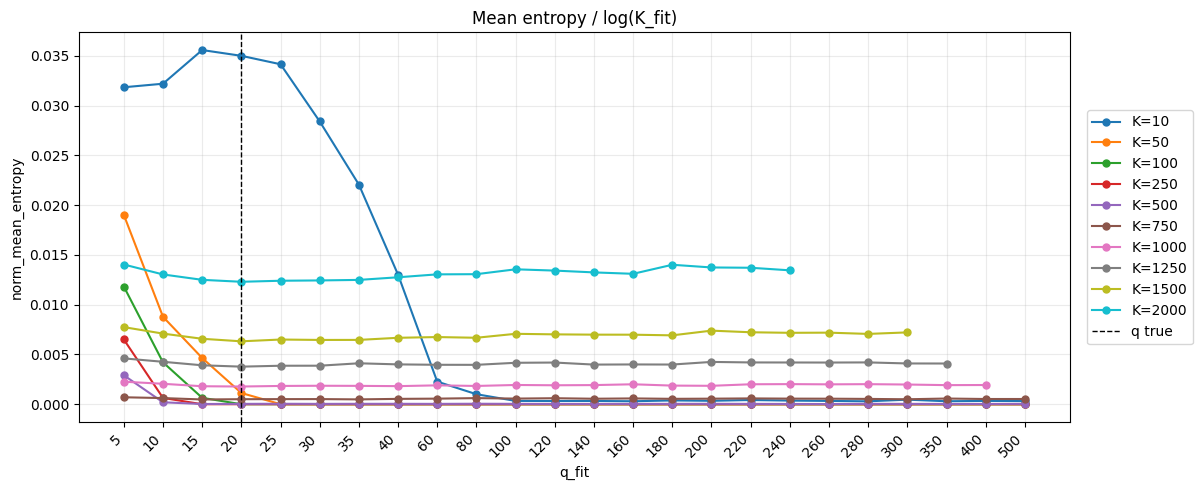

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/norm_mean_entropy_vs_q.png


In [11]:
plot_metric_vs_q("norm_mean_entropy")

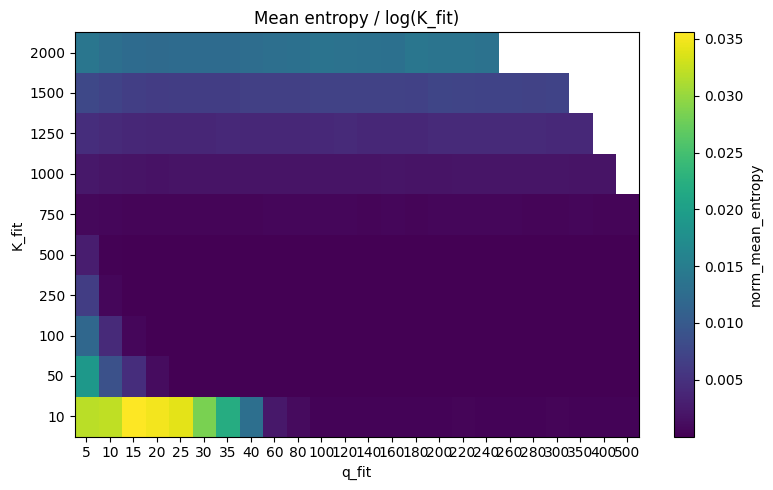

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/norm_mean_entropy_heatmap.png


In [12]:
plot_metric_heatmap("norm_mean_entropy")

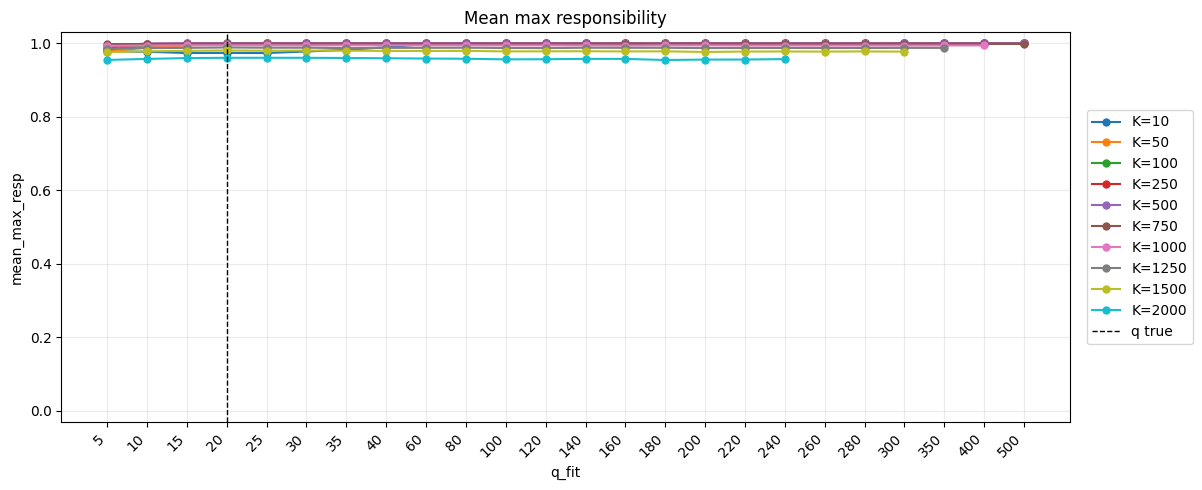

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/mean_max_resp_vs_q.png


In [13]:
plot_metric_vs_q("mean_max_resp")

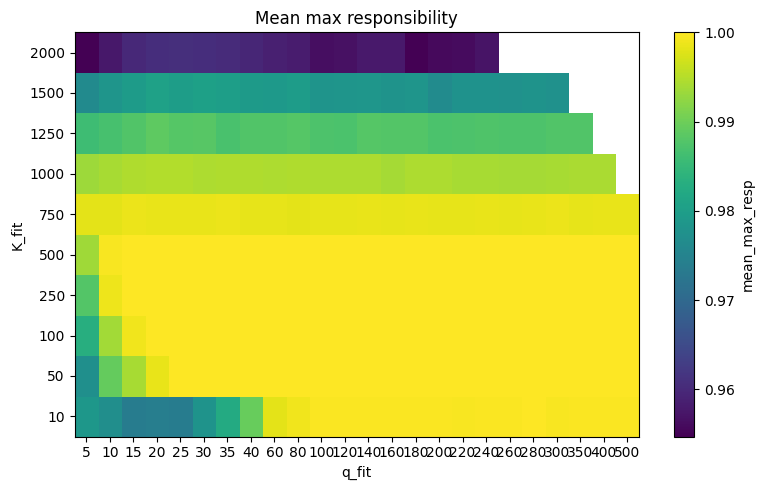

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/mean_max_resp_heatmap.png


In [14]:
plot_metric_heatmap("mean_max_resp")

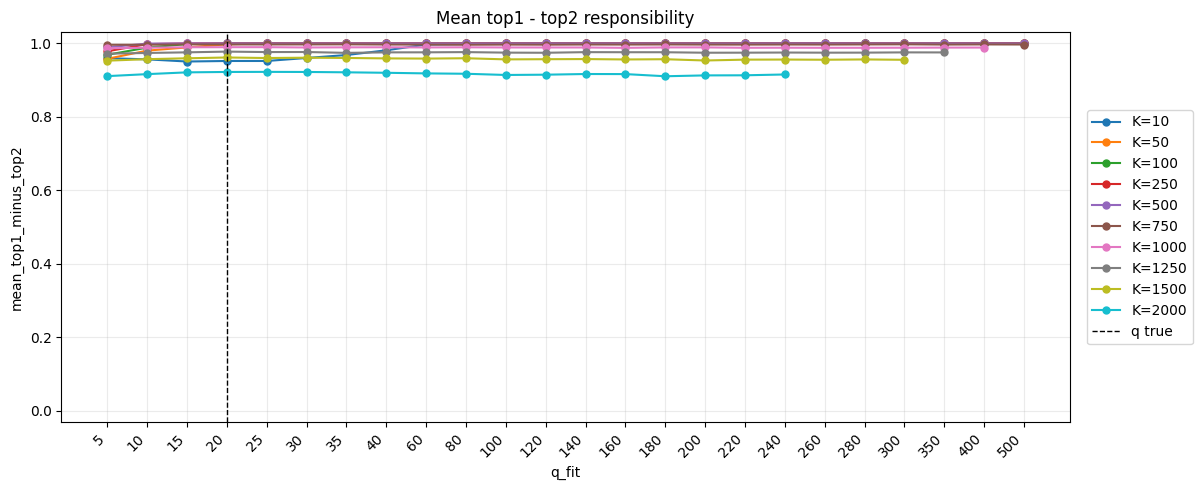

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/mean_top1_minus_top2_vs_q.png


In [15]:
plot_metric_vs_q("mean_top1_minus_top2")

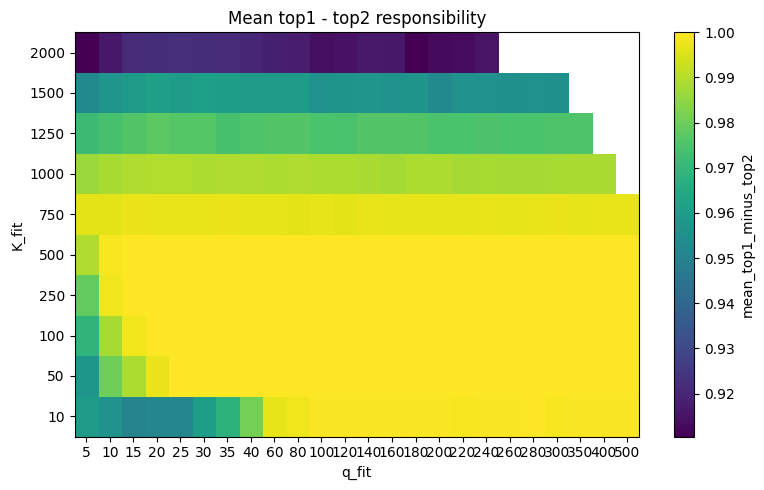

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/mean_top1_minus_top2_heatmap.png


In [16]:
plot_metric_heatmap("mean_top1_minus_top2")

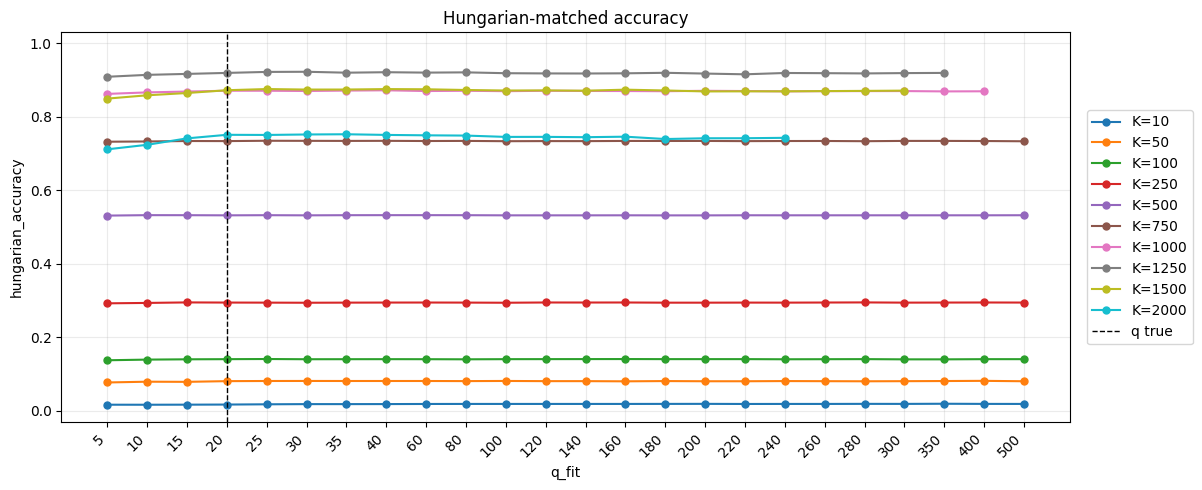

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/hungarian_accuracy_vs_q.png


In [17]:
plot_metric_vs_q("hungarian_accuracy")

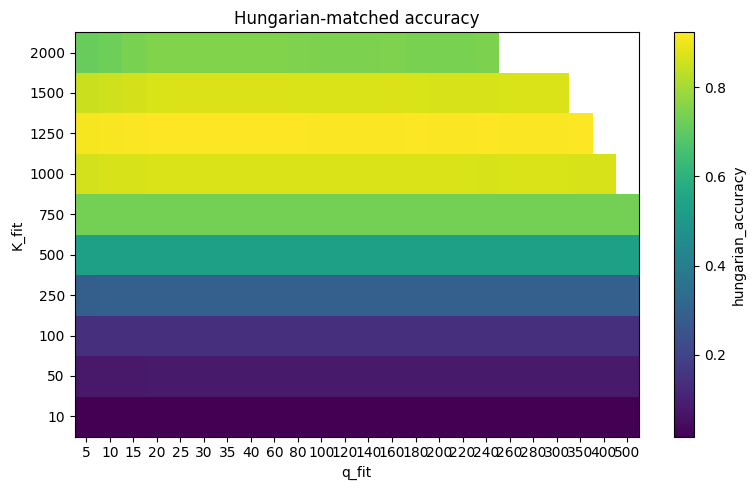

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/hungarian_accuracy_heatmap.png


In [18]:
plot_metric_heatmap("hungarian_accuracy")

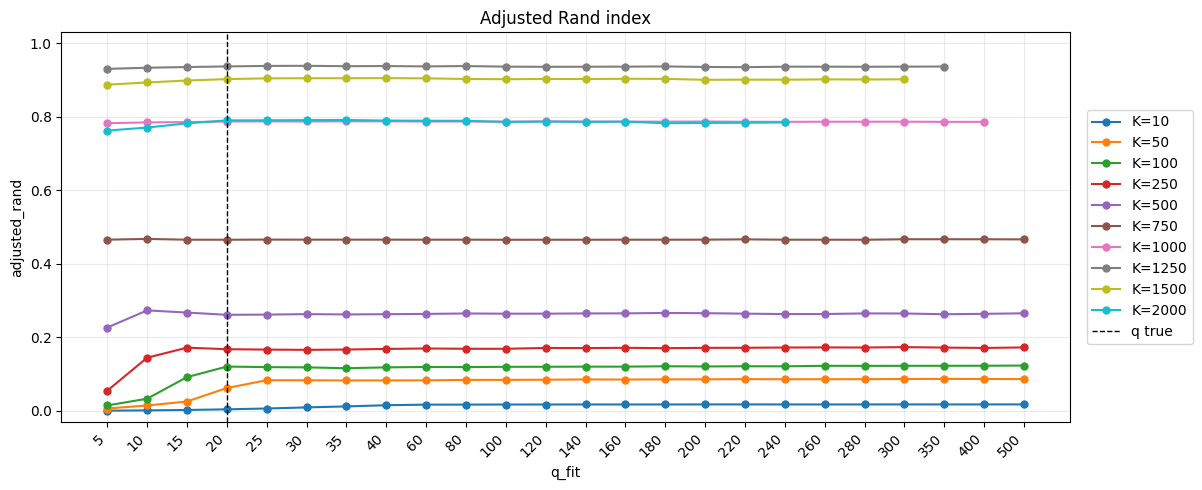

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/adjusted_rand_vs_q.png


In [19]:
plot_metric_vs_q("adjusted_rand")

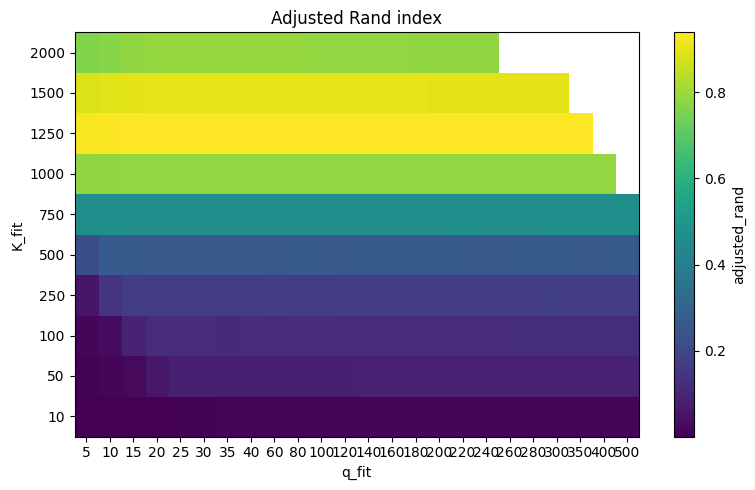

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/adjusted_rand_heatmap.png


In [20]:
plot_metric_heatmap("adjusted_rand")

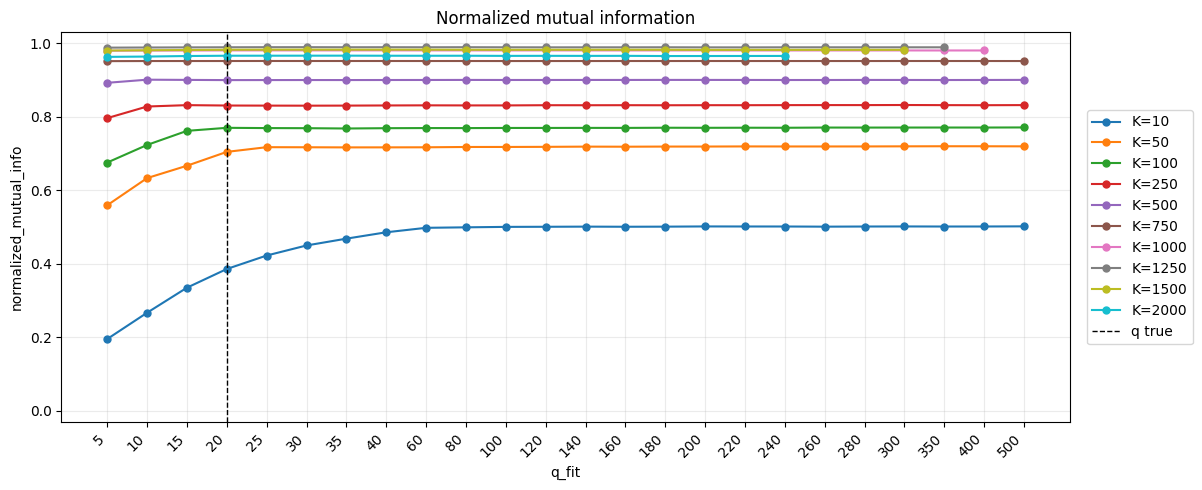

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/normalized_mutual_info_vs_q.png


In [21]:
plot_metric_vs_q("normalized_mutual_info")

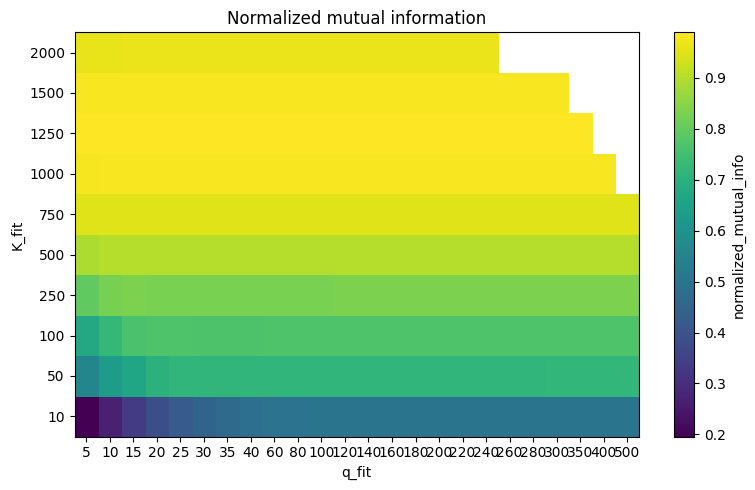

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/normalized_mutual_info_heatmap.png


In [22]:
plot_metric_heatmap("normalized_mutual_info")

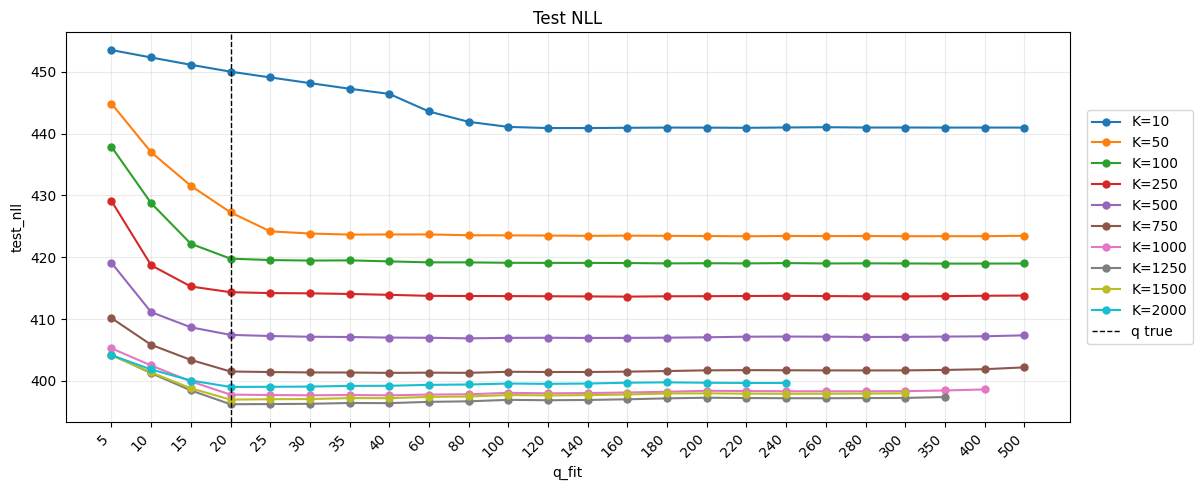

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/test_nll_vs_q.png


In [23]:
plot_metric_vs_q("test_nll")

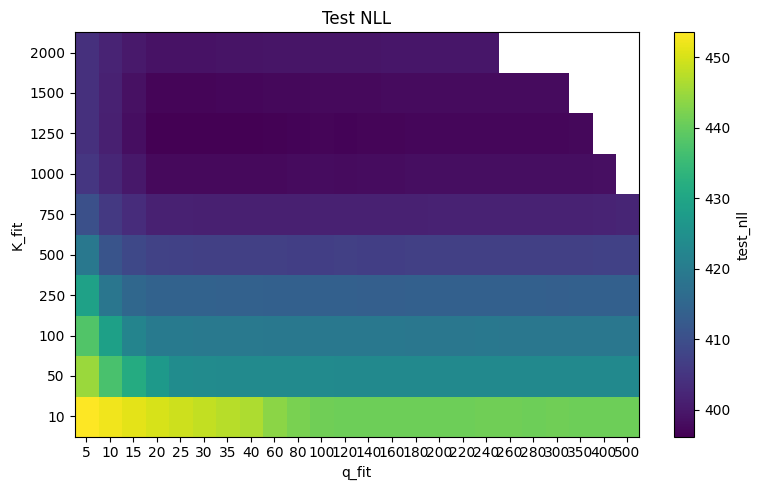

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/test_nll_heatmap.png


In [24]:
plot_metric_heatmap("test_nll")

## Feature splitting & covariance reconstruction

When `K_fit > K_true` (here `K_true = 1000`), a single ground-truth (g.t.) region
may be represented by several fitted components — **feature splitting**. Two
questions:

1. **Does splitting happen?** Map every fitted component to the g.t. cluster that
   owns most of the test points it captures (using the true labels `y_test`). The
   *split factor* of a g.t. cluster is how many fitted components map to it.
2. **Does summing the split Gaussians reconstruct the original?** Moment-match the
   merged sub-mixture into a single Gaussian `N(mu_bar, C_merged)` and compare it
   to the g.t. Gaussian `N(mu_gt, C_gt)` via the **covariance difference**
   `||C_merged - C_gt||_F / ||C_gt||_F` and a **distributional distance**
   (Bhattacharyya `D_B`, symmetric KL as a cross-check), each against a
   single-component baseline. Expected: for `q_fit < q_true=20` a single low-rank
   component cannot capture the rank-20 cluster, so the model splits and merging
   the splits recovers `C_gt` better than any single component; the merge benefit
   shrinks as `q_fit -> q_true`.

**Workflow.** The heavy computation lives in
`scripts/synthetic_mfa_feature_splitting.py` (run it on a GPU / the cluster); it
writes `feature_splitting.csv` and `feature_splitting.pt` into the run directory.
The cells below only **load and plot** those results. To get plots for a
`(K_fit, q_fit)` that has not been computed yet, run e.g.

```
PYTHONPATH=src python scripts/synthetic_mfa_feature_splitting.py \
    --run-dir <RUN_DIR> --only '1500:20'
```

then re-run the loader cell below.


In [25]:
# Load precomputed feature-splitting results from the analysis script.
# The heavy computation lives in scripts/synthetic_mfa_feature_splitting.py;
# this notebook only plots its output.
import pandas as pd

SPLIT_PT = RUN_DIR / "feature_splitting.pt"
if not SPLIT_PT.exists():
    raise FileNotFoundError(
        f"{SPLIT_PT} not found. Run the analysis script first, e.g.:\n"
        f"  PYTHONPATH=src python scripts/synthetic_mfa_feature_splitting.py "
        f"--run-dir {RUN_DIR} --k-min 750"
    )

_split = torch.load(SPLIT_PT, map_location="cpu", weights_only=False)
split_df = pd.DataFrame(_split["agg"]).sort_values(["K_fit", "q_fit", "seed"]).reset_index(drop=True)
split_factor_hist = _split["split_factor_hist"]   # (K_fit, q_fit, seed) -> tensor[K_true]
eig_spectra = _split.get("eig_spectra", {})       # (K_fit, q_fit, seed) -> {gt, merged, single}
K_TRUE = int(_split["meta"]["K_true"])
Q_TRUE = int(_split["meta"]["q_true"])

COMPUTED_FITS = sorted(split_factor_hist)
print(f"loaded {len(split_df)} fits; K_true={K_TRUE} q_true={Q_TRUE}")
print("computed (K_fit, q_fit, seed):", COMPUTED_FITS)


def require_fit(K_fit, q_fit, seed=0):
    """True if results exist; else explain how to compute them and return False."""
    if (K_fit, q_fit, seed) in split_factor_hist:
        return True
    print(
        f"No precomputed results for K_fit={K_fit}, q_fit={q_fit}, seed={seed}.\n"
        f"Compute them with:\n"
        f"  PYTHONPATH=src python scripts/synthetic_mfa_feature_splitting.py "
        f"--run-dir {RUN_DIR} --only '{K_fit}:{q_fit}'\n"
        f"Available: {COMPUTED_FITS}"
    )
    return False


display(split_df)


loaded 108 fits; K_true=1000 q_true=20
computed (K_fit, q_fit, seed): [(750, 5, 0), (750, 10, 0), (750, 15, 0), (750, 20, 0), (750, 25, 0), (750, 30, 0), (750, 35, 0), (750, 40, 0), (750, 60, 0), (750, 80, 0), (750, 100, 0), (750, 120, 0), (750, 140, 0), (750, 160, 0), (750, 180, 0), (750, 200, 0), (750, 220, 0), (750, 240, 0), (750, 260, 0), (750, 280, 0), (750, 300, 0), (750, 350, 0), (750, 400, 0), (750, 500, 0), (1000, 5, 0), (1000, 10, 0), (1000, 15, 0), (1000, 20, 0), (1000, 25, 0), (1000, 30, 0), (1000, 35, 0), (1000, 40, 0), (1000, 60, 0), (1000, 80, 0), (1000, 100, 0), (1000, 120, 0), (1000, 140, 0), (1000, 160, 0), (1000, 180, 0), (1000, 200, 0), (1000, 220, 0), (1000, 240, 0), (1000, 260, 0), (1000, 280, 0), (1000, 300, 0), (1000, 350, 0), (1000, 400, 0), (1250, 5, 0), (1250, 10, 0), (1250, 15, 0), (1250, 20, 0), (1250, 25, 0), (1250, 30, 0), (1250, 35, 0), (1250, 40, 0), (1250, 60, 0), (1250, 80, 0), (1250, 100, 0), (1250, 120, 0), (1250, 140, 0), (1250, 160, 0), (1250, 180

,K_fit,q_fit,seed,n_covered,coverage,mean_split_factor,frac_split,frob_merged_mean,frob_single_mean,db_merged_mean,db_single_mean,skl_merged_mean,skl_single_mean,mean_err_mean
0,750,5,0,722,0.722,1.037396,0.037396,0.602326,0.602825,3.208586,3.225594,18.010761,18.107179,0.162368
1,750,10,0,722,0.722,1.036011,0.036011,0.559653,0.560039,2.698124,2.715388,15.725385,15.823627,0.162587
2,750,15,0,722,0.722,1.033241,0.033241,0.521869,0.522512,2.411378,2.429462,14.103208,14.202914,0.162790
3,750,20,0,722,0.722,1.033241,0.033241,0.484631,0.485464,2.199826,2.220092,12.668476,12.776631,0.162822
4,750,25,0,722,0.722,1.030471,0.030471,0.482820,0.482933,2.104905,2.118190,12.181585,12.252431,0.163041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,2000,160,0,1000,1.000,1.867000,0.703000,0.466821,0.473678,2.045490,2.522159,9.451008,12.009592,0.096927
104,2000,180,0,1000,1.000,1.875000,0.707000,0.485442,0.489059,2.037691,2.412397,9.602384,11.664477,0.096606
105,2000,200,0,1000,1.000,1.877000,0.712000,0.482575,0.486692,2.026518,2.419602,9.518681,11.670157,0.096324
106,2000,220,0,1000,1.000,1.873000,0.706000,0.480123,0.484852,2.025703,2.434739,9.488368,11.717559,0.096887


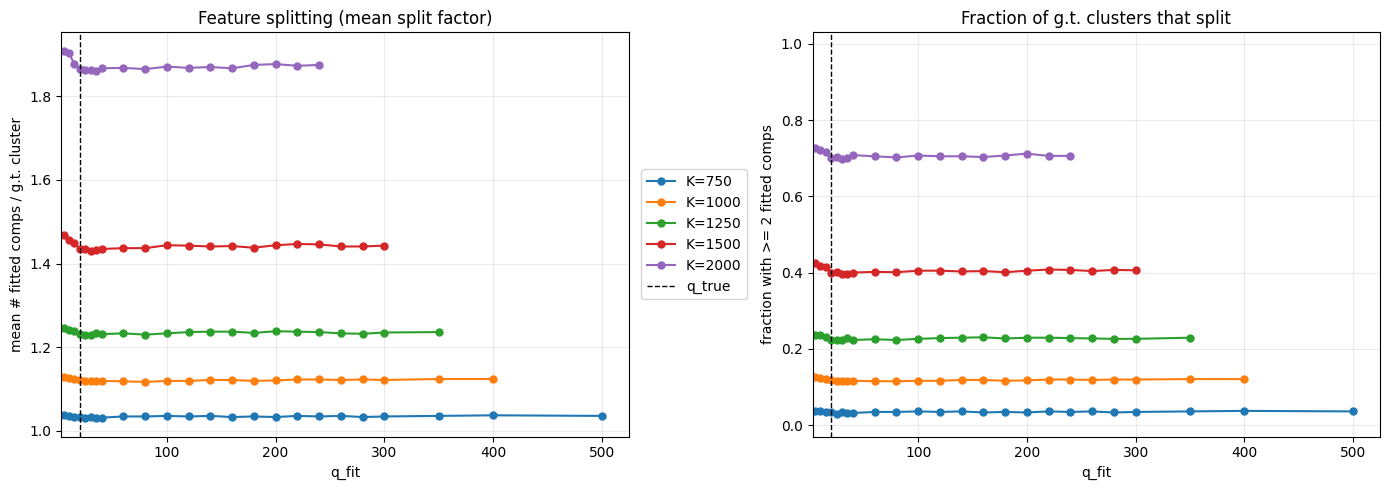

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/feature_splitting_vs_q.png


In [26]:
# --- Splitting vs q: mean split factor and fraction of split g.t. clusters ---
# q starts at 5!! the plot start from 0 but it's just matplotlib being matplotlib; the first point is at q=5
def _plot_split_metric(ax, col, ylabel):
    for K in sorted(split_df["K_fit"].unique()):
        sub = split_df[split_df["K_fit"] == K].sort_values("q_fit")
        ax.plot(sub["q_fit"], sub[col], marker="o", linewidth=1.5, markersize=5, label=f"K={K}")
    ax.axvline(Q_TRUE, color="black", linestyle="--", linewidth=1, label="q_true")
    ax.set_xlabel("q_fit")
    ax.set_ylabel(ylabel)
    ax.set_xlim(left=split_df["q_fit"].min() - 2)  # experiments start at q_fit=5; avoid a spurious 0 tick
    ax.grid(True, alpha=0.25)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_plot_split_metric(axes[0], "mean_split_factor", "mean # fitted comps / g.t. cluster")
axes[0].set_title("Feature splitting (mean split factor)")
_plot_split_metric(axes[1], "frac_split", "fraction with >= 2 fitted comps")
axes[1].set_title("Fraction of g.t. clusters that split")
axes[1].set_ylim(-0.03, 1.03)
axes[0].legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True)
save_and_show(fig, PLOT_DIR / "feature_splitting_vs_q.png")


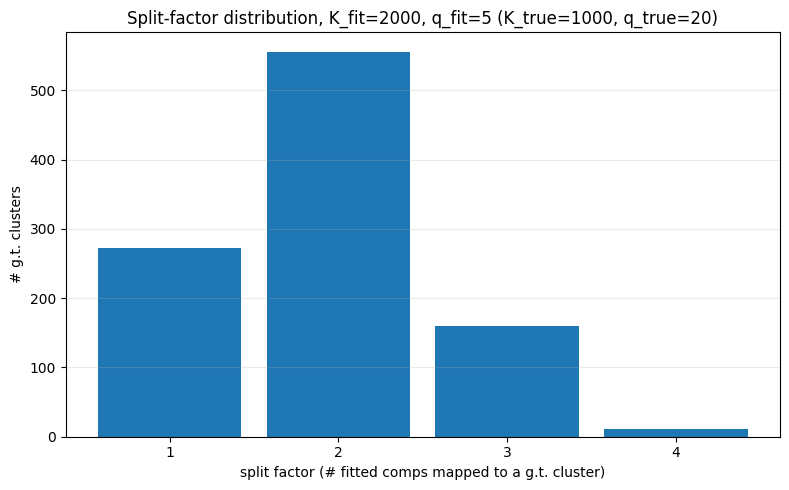

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/split_factor_hist_K2000_q0005.png


In [27]:
# Split-factor histogram for one (K_fit, q_fit): how many ways g.t. clusters split.
# Default = largest computed K_fit at its smallest q_fit (most splitting expected).
HIST_K = max(k for (k, q, s) in COMPUTED_FITS)
HIST_Q = min(q for (k, q, s) in COMPUTED_FITS if k == HIST_K)
HIST_SEED = min(s for (k, q, s) in COMPUTED_FITS if k == HIST_K and q == HIST_Q)

if require_fit(HIST_K, HIST_Q, HIST_SEED):
    sf = split_factor_hist[(HIST_K, HIST_Q, HIST_SEED)]
    covered = sf[sf > 0]
    max_f = int(covered.max())
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(covered.numpy(), bins=range(1, max_f + 2), align="left", rwidth=0.85)
    ax.set_xticks(range(1, max_f + 1))
    ax.set_xlabel("split factor (# fitted comps mapped to a g.t. cluster)")
    ax.set_ylabel("# g.t. clusters")
    ax.set_title(
        f"Split-factor distribution, K_fit={HIST_K}, q_fit={HIST_Q} "
        f"(K_true={K_TRUE}, q_true={Q_TRUE})"
    )
    ax.grid(True, axis="y", alpha=0.25)
    save_and_show(fig, PLOT_DIR / f"split_factor_hist_K{HIST_K:04d}_q{HIST_Q:04d}.png")


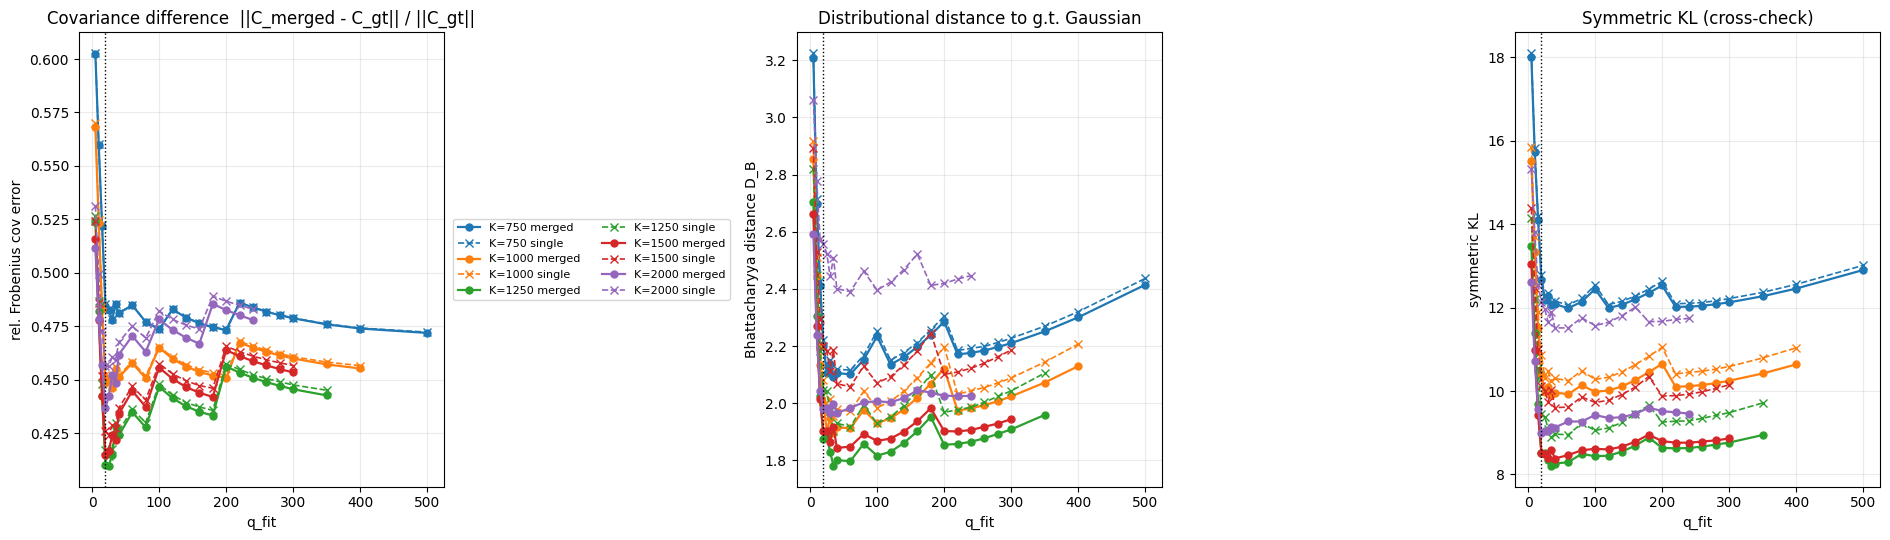

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/feature_splitting_reconstruction_vs_q.png


In [28]:
# --- Reconstruction: does summing the split Gaussians recover the original? ---
# Solid = merged sub-mixture (moment-matched), dashed = best single component.
def _plot_recon(ax, base, ylabel):
    for K in sorted(split_df["K_fit"].unique()):
        sub = split_df[split_df["K_fit"] == K].sort_values("q_fit")
        line, = ax.plot(
            sub["q_fit"], sub[f"{base}_merged_mean"],
            marker="o", linewidth=1.6, markersize=5, label=f"K={K} merged",
        )
        ax.plot(
            sub["q_fit"], sub[f"{base}_single_mean"],
            marker="x", linestyle="--", linewidth=1.2, color=line.get_color(),
            label=f"K={K} single",
        )
    ax.axvline(Q_TRUE, color="black", linestyle=":", linewidth=1)
    ax.set_xlabel("q_fit")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)


fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
_plot_recon(axes[0], "frob", "rel. Frobenius cov error")
axes[0].set_title("Covariance difference  ||C_merged - C_gt|| / ||C_gt||")
_plot_recon(axes[1], "db", "Bhattacharyya distance D_B")
axes[1].set_title("Distributional distance to g.t. Gaussian")
_plot_recon(axes[2], "skl", "symmetric KL")
axes[2].set_title("Symmetric KL (cross-check)")
axes[0].legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8, ncol=2, frameon=True)
save_and_show(fig, PLOT_DIR / "feature_splitting_reconstruction_vs_q.png")


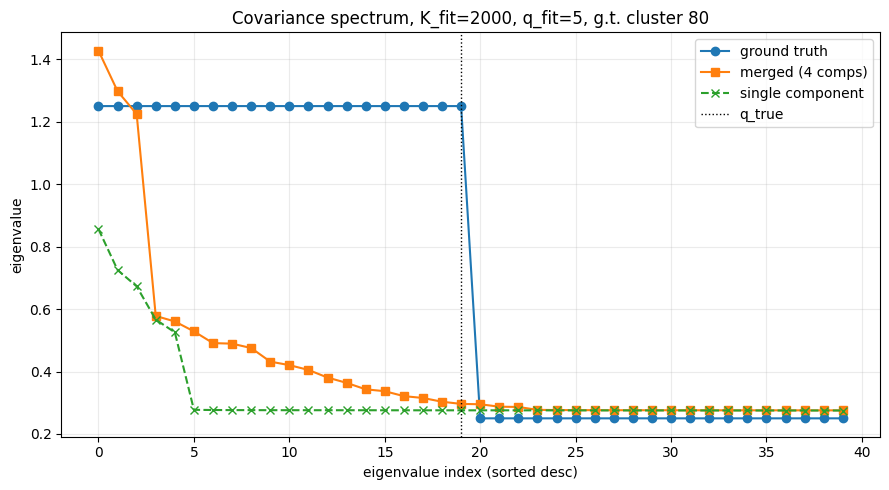

/orfeo/cephfs/home/dssc/zenocosini/decomposing-activations-local-geometry/dalg-cache/qk_sweep_exploration/Ktrue1000_qtrue20/notebook_plots/eig_spectrum_K2000_q0005.png


In [29]:
# Eigenvalue spectra (saved by the script) for the most-split g.t. cluster of one fit.
# Shows how merging refills the covariance rank a single q_fit<q_true comp misses.
if not eig_spectra:
    print(
        "No eigenspectra saved. Recompute with the analysis script (it stores them per fit):\n"
        f"  PYTHONPATH=src python scripts/synthetic_mfa_feature_splitting.py "
        f"--run-dir {RUN_DIR} --k-min 750"
    )
else:
    EIG_K = max(k for (k, q, s) in eig_spectra)
    EIG_Q = min(q for (k, q, s) in eig_spectra if k == EIG_K)
    EIG_SEED = min(s for (k, q, s) in eig_spectra if k == EIG_K and q == EIG_Q)
    rec = eig_spectra[(EIG_K, EIG_Q, EIG_SEED)]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(rec["gt"], marker="o", label="ground truth")
    ax.plot(rec["merged"], marker="s", label=f"merged ({rec['n']} comps)")
    ax.plot(rec["single"], marker="x", linestyle="--", label="single component")
    ax.axvline(Q_TRUE - 1, color="black", linestyle=":", linewidth=1, label="q_true")
    ax.set_xlabel("eigenvalue index (sorted desc)")
    ax.set_ylabel("eigenvalue")
    ax.set_title(f"Covariance spectrum, K_fit={EIG_K}, q_fit={EIG_Q}, g.t. cluster {rec['cluster']}")
    ax.grid(True, alpha=0.25)
    ax.legend()
    save_and_show(fig, PLOT_DIR / f"eig_spectrum_K{EIG_K:04d}_q{EIG_Q:04d}.png")
